In [3]:
from google.colab import files
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import numpy as np

In [ ]:
#import disease symptom dataset
files.upload()

In [4]:
#reads a comma-separated values (csv) file and converts it into DataFrame
ds_set = pd.read_csv("Final_Augmented_dataset_Diseases_and_Symptoms.csv")

In [6]:
#outputs what the first few rows of the dataframe looks like
ds_set.head()

,diseases,anxiety and nervousness,depression,shortness of breath,depressive or psychotic symptoms,sharp chest pain,dizziness,insomnia,abnormal involuntary movements,chest tightness,...,stuttering or stammering,problems with orgasm,nose deformity,lump over jaw,sore in nose,hip weakness,back swelling,ankle stiffness or tightness,ankle weakness,neck weakness
0,panic disorder,1,0,1,1,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
1,panic disorder,0,0,1,1,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
2,panic disorder,1,1,1,1,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
3,panic disorder,1,0,0,1,0,1,1,1,0,...,0,0,0,0,0,0,0,0,0,0
4,panic disorder,1,1,0,0,0,0,1,1,1,...,0,0,0,0,0,0,0,0,0,0


In [7]:
#outputs information about the dataframe
ds_set.info()
ds_set.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 246945 entries, 0 to 246944
Columns: 378 entries, diseases to neck weakness
dtypes: int64(377), object(1)
memory usage: 712.2+ MB


(246945, 378)

In [8]:
# DATA CLEANING

#checks for missing values
ds_set.isnull().sum()

,0
diseases,0
anxiety and nervousness,0
depression,0
shortness of breath,0
depressive or psychotic symptoms,0
...,...
hip weakness,0
back swelling,0
ankle stiffness or tightness,0
ankle weakness,0


In [5]:
#checks and removes duplicate rows
print(ds_set.duplicated().sum())
ds_set = ds_set.drop_duplicates()

57298


In [6]:
#focus on symptom columns
symptoms = ds_set.drop(columns=["diseases"])

In [11]:
#checks for rows with all 0s
zero_rows = ds_set[symptoms.sum(axis=1) == 0]
print(zero_rows)

Empty DataFrame
Columns: [diseases, anxiety and nervousness, depression, shortness of breath, depressive or psychotic symptoms, sharp chest pain, dizziness, insomnia, abnormal involuntary movements, chest tightness, palpitations, irregular heartbeat, breathing fast, hoarse voice, sore throat, difficulty speaking, cough, nasal congestion, throat swelling, diminished hearing, lump in throat, throat feels tight, difficulty in swallowing, skin swelling, retention of urine, groin mass, leg pain, hip pain, suprapubic pain, blood in stool, lack of growth, emotional symptoms, elbow weakness, back weakness, pus in sputum, symptoms of the scrotum and testes, swelling of scrotum, pain in testicles, flatulence, pus draining from ear, jaundice, mass in scrotum, white discharge from eye, irritable infant, abusing alcohol, fainting, hostile behavior, drug abuse, sharp abdominal pain, feeling ill, vomiting, headache, nausea, diarrhea, vaginal itching, vaginal dryness, painful urination, involuntary ur

In [12]:
#checks class distribution
ds_set['diseases'].value_counts()

,count
diseases,
cystitis,1219
nose disorder,1218
vulvodynia,1218
complex regional pain syndrome,1217
spondylosis,1216
...,...
open wound of the cheek,1
open wound of the knee,1
rheumatic fever,1


/tmp/ipykernel_15031/4287448295.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top20.values, y=top20.index, palette='flare')


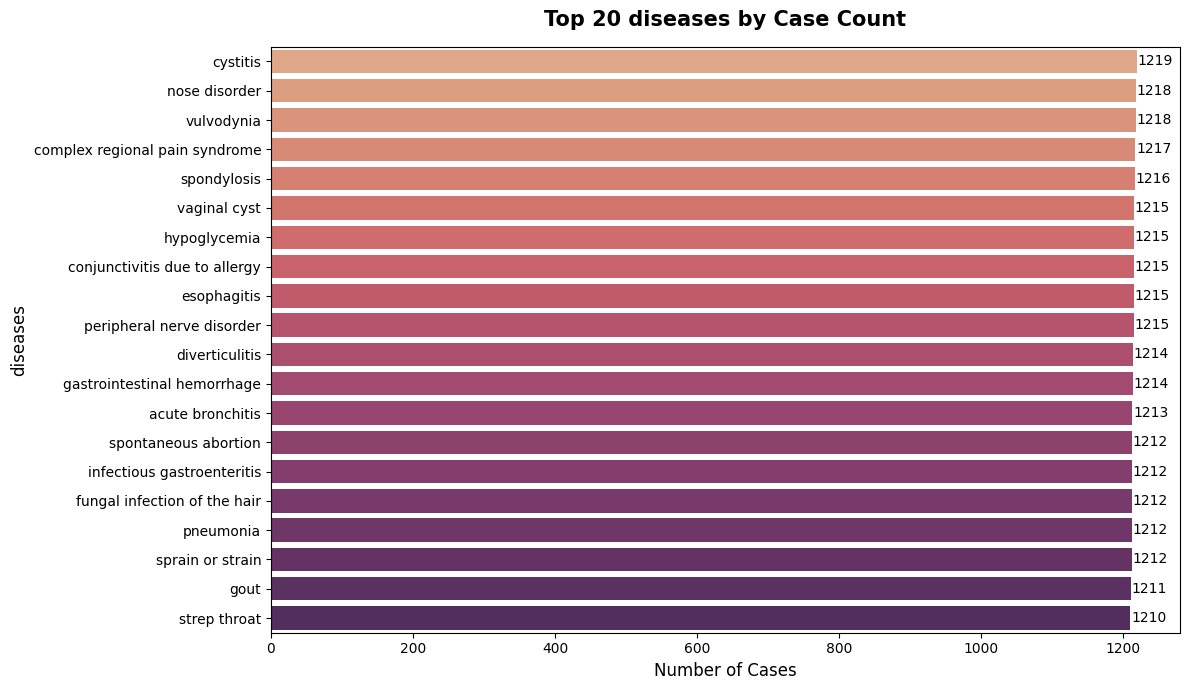

In [13]:
# DATA ANALYSIS/VISUALISATION

#get top 20 diseases by count
top20 = ds_set['diseases'].value_counts().head(20)

#plot
plt.figure(figsize=(12, 7))
sns.barplot(x=top20.values, y=top20.index, palette='flare')

plt.title('Top 20 diseases by Case Count', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Number of Cases', fontsize=12)
plt.ylabel('diseases', fontsize=12)

for i, v in enumerate(top20.values):
    plt.text(v + 1, i, str(v), va='center', fontsize=10)

plt.tight_layout()
plt.show()

/tmp/ipykernel_15031/2754558891.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top20.values, y=top20.index, palette='flare')


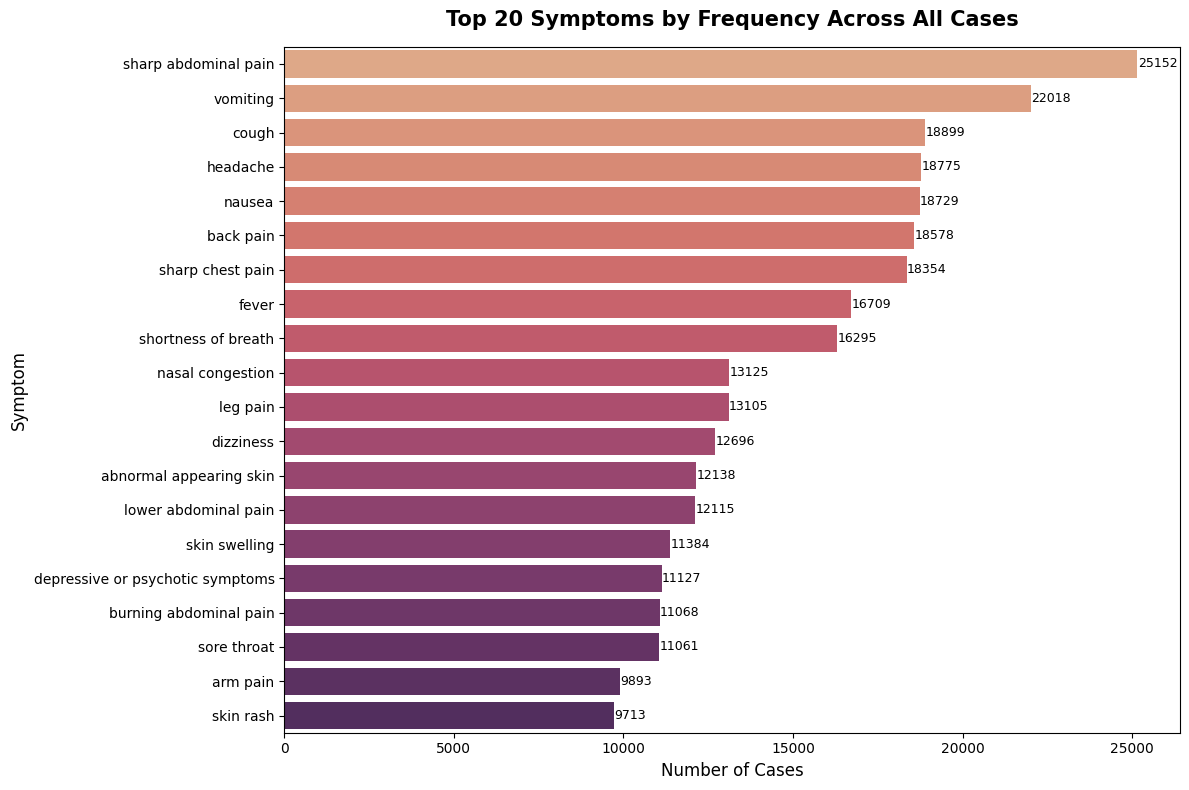

In [15]:
#get top 20 symptoms by count
symptom_freq = symptoms.sum().sort_values(ascending=False)
top20 = symptom_freq.head(20).sort_values(ascending=False)

#plot
plt.figure(figsize=(12, 8))
sns.barplot(x=top20.values, y=top20.index, palette='flare')

plt.title('Top 20 Symptoms by Frequency Across All Cases', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Number of Cases', fontsize=12)
plt.ylabel('Symptom', fontsize=12)

#loop over top20 only, not the full symptom_freq
for i, v in enumerate(top20.values):
    plt.text(v + 10, i, str(v), va='center', fontsize=9)

plt.tight_layout()
plt.show()

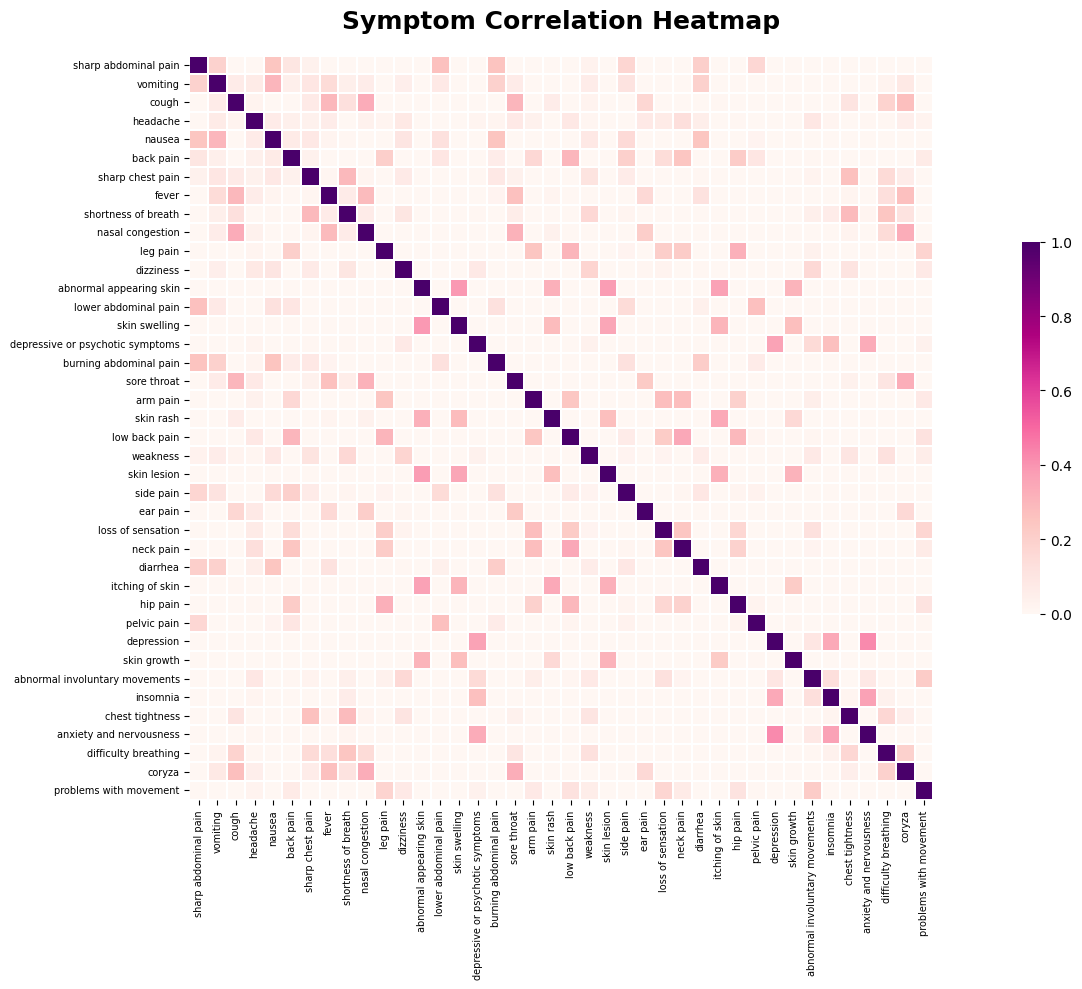

In [10]:
#compute correlation matrix - only include top 40 most frequent symptoms
top40 = symptoms.sum().sort_values(ascending=False).head(40).index
corr_matrix = symptoms[top40].corr()

#plot
plt.figure(figsize=(18, 10))
sns.heatmap(
    corr_matrix,
    cmap='RdPu',
    vmin=0,
    vmax=1,
    square=True,
    linewidths=0.3,
    annot=False,
    cbar_kws={"shrink": 0.5}
)

plt.title('Symptom Correlation Heatmap', fontsize=18, fontweight='bold', pad=20)
plt.xticks(rotation=90, fontsize=7)
plt.yticks(rotation=0, fontsize=7)
plt.tight_layout()
plt.show()